In [ ]:
import numpy as np
import pandas as pd
#from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'

In [39]:
df = pd.read_csv("dataset/archive/car data.csv")

#print(df.head())

car_df_encoded = pd.get_dummies(df, columns=['Car_Name', 'Fuel_Type', 'Seller_Type', 'Transmission'], drop_first=True)

car_df_encoded.head()


,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Name_Activa 3g,Car_Name_Activa 4g,Car_Name_Bajaj ct 100,Car_Name_Bajaj Avenger 150,Car_Name_Bajaj Avenger 150 street,...,Car_Name_swift,Car_Name_sx4,Car_Name_verna,Car_Name_vitara brezza,Car_Name_wagon r,Car_Name_xcent,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,2014,3.35,5.59,27000,0,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
1,2013,4.75,9.54,43000,0,False,False,False,False,False,...,False,True,False,False,False,False,True,False,False,True
2,2017,7.25,9.85,6900,0,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
3,2011,2.85,4.15,5200,0,False,False,False,False,False,...,False,False,False,False,True,False,False,True,False,True
4,2014,4.60,6.87,42450,0,False,False,False,False,False,...,True,False,False,False,False,False,True,False,False,True


In [41]:
X = car_df_encoded.drop('Selling_Price', axis=1)
y = car_df_encoded['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


인공지능의 가격 예측 정확도 점수 : 96.69점 / 100점


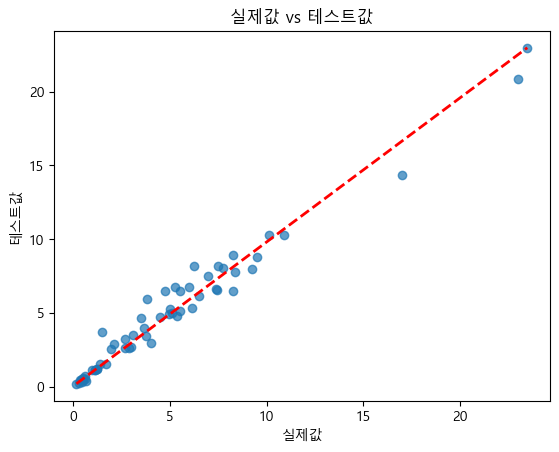

In [43]:
score = r2_score(y_test, y_pred)
print(f"인공지능의 가격 예측 정확도 점수 : {score * 100:.2f}점 / 100점")

plt.figure()
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_pred.min(), y_pred.max()], '--r', lw=2)
plt.xlabel('실제값')
plt.ylabel('테스트값')
plt.title('실제값 vs 테스트값')
plt.show()

In [45]:
import joblib
joblib.dump(model, 'car_price_model.pkl')
print("모델 저장 완료")

모델 저장 완료


In [46]:
joblib.dump(X.columns, 'model_columns.pkl')

['model_columns.pkl']